## A Brief Introduction to Grover's Algorithm

Grover's Algorithm is named after it's creator Lov Grover, who wrote a paper titled *A fast quantum mechanical algorithm for database search* (Grover). It reduces an the number of operations required to search an *unstructured* database from $O(N)$ operations to $O(\sqrt N)$ operations.

It relies on the fact that Quantum mechanical systems can do several operations simultaneously due to their wave like properties. 

---

**In project I investigate Grover's Algorithm for unstructured search problems. It is broken down into 4 sections**

- **Section 1** : Implement Grover’s algorithm for a sequence of increasingly large search spaces and compare with classical brute-force search

- **Section 2:** Investigate why Grover's algorithm scales with $\sqrt N$ and provide theoretical foundation

- **Section 3:** Show some more advanced versions of Grover's Algorithm with a different Oracle Function

- **Section 4:** Outlook

- **Section 5:** Acknowledgements and References

Choice of packages: `Qiskit`

Qiskit is a software stack for quantum computing and is developed by IBM

Choice of packages: `Qiskit Aer`

Qiskit Aer is a simulator that allows users to simulate noise. The impact of quantum noise on Grover's Algorithm is discussed at the end of the report.

In [1]:
#Preliminaries - Quantum Module Import
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit_aer import AerSimulator

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import IntegerComparator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram

#Standard Import - some standard module that will help with analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

### Section 1
**Objective:** Direct comparison of classical methods (brute force) with a quantum method (Grover's Algorithm) to search for a bitstring of length $n$ in a sample size $N = 2^n$

---

### **Method**

1. **Build a function to generate a string of random bitstrings**

2. **Build a Grover Circuit and Classical Algorithm to find each bitstring and test for n = 4**

3. **Test classical and quantum methods, compare for bitstring of length 4 and plot results.**
   - Visualise Grover Circuit and number of operations.

4. **Scale analysis different number of bitstrings**  
   - Compare required tests to find a given bitstring and compare as $N$ grows


In [2]:
#1. Function to generate bitstrings and store in a dataframe, define the seed for control
def generate_random_bitstrings(seed=None):
    if seed is not None:
        np.random.seed(seed)
    data = []
    for n in range(1, 11):
        bits = np.random.randint(0, 2, size=n)
        bitstring = ''.join(bits.astype(str))
        combinations = 2**n
        data.append([n, bitstring, combinations])
    df = pd.DataFrame(data, columns=["N (Bits)", "Random Bitstring", "Possible Outcomes"])
    return df
df_bitstrings = generate_random_bitstrings(seed=24)
#Function to locate 1 bitstring of length control_k
def bitlookup(n):
    row = df_bitstrings[df_bitstrings["N (Bits)"] == n]
    bitstring = row["Random Bitstring"].iloc[0]
    outcomes = row["Possible Outcomes"].iloc[0]
    return bitstring, outcomes
def make_combination_lock(secret_code: str): #An oracle that holds the secret key and returns yes/no answer when queried
    def lock(guess: str) -> bool:
        return guess == secret_code
    return lock

In [3]:
#2.1 Build the classical brute force approachl, where all possible combinations are tested until the correct one is found
def all_k_bit_codes(k: int):
    N = 2 ** k
    ints = np.arange(N, dtype=int)
    return [f"{x:0{k}b}" for x in ints]

def classical_hack(k: int, lock_fn):
    candidates = all_k_bit_codes(k)
    for i, guess in enumerate(candidates, start=1):
        if lock_fn(guess):
            return guess, i
    return None, len(candidates) 

def test_classical(df, k: int):
    row = df.loc[df["N (Bits)"] == k].iloc[0]
    secret = row["Random Bitstring"]
    lock = make_combination_lock(secret)
    found, queries = classical_hack(k, lock)
    return {"k": k,"secret": secret,"found": found,"queries": queries,"success": (found == secret),}

## Aside: Grover’s Algorithm: Oracle, Diffusion Operator, and Iteration Count

To implement Grover’s algorithm for searching an unstructured database of size  $N = 2^n$ we construct two key components:

---

**i. Phase Oracle \( O \)**  
The oracle marks the unknown solution state $|z\rangle$ = $|\text{secret\_bitstring}\rangle$ by applying a phase flip:


$O|x\rangle$ =
$\begin{cases}
-|x\rangle, & x = z \\
\ \ |x\rangle, & x \neq z
\end{cases}$

To achieve this using standard qubit operations, we:

1. **Apply X gates** to convert the target bitstring into $|11\ldots1\rangle$
2. **Use a multi-controlled Z** (via the H–MCX–H construction) to apply the sign flip.  
3. **Undo the X gates** to restore the computational basis.

This produces a clean phase oracle acting only on the marked state.

---

**ii. Diffusion Operator \( D \)**  
The diffusion operator performs *inversion about the average*, amplifying the amplitude of the marked state.  
Mathematically:


$D = 2|\psi\rangle\!\langle\psi| - I
\quad\text{where}\quad
|\psi\rangle = H^{\otimes n} |0\rangle^{\otimes n}$


The standard implementation:

1. Apply H on all qubits  
2. Apply X on all qubits  
3. Apply a controlled phase flip on \(|11\ldots1\rangle\)  
4. Undo the X and H layers  

This reflects each amplitude about their global average, boosting the marked state after each iteration.

---

**iii. Number of Grover Iterations \( T \)**  
Grover’s algorithm is a rotation in a 2D subspace spanned by:

- $|z\rangle$ - the marked state  
- $|A_0\rangle$ - the uniform superposition of all non-marked states

Each Grover iteration (Oracle + Diffusion) rotates the state vector by: $2\theta \approx \frac{2}{\sqrt{N}}$, meaning the optimal number of iterations that maximises success probability is: $ T \approx \left\lfloor \frac{\pi}{4}\sqrt{N} \right\rfloor$

This is the value used in the implementation below, I discuss it's origin and meaning in *Section 2*

---

### Building The Circuit  
The complete Grover circuit prepares the uniform state and performs $T$ iterations before measuring it in the computational basis to recover the secret bitstring with high probability

In [4]:
#2.2 Build the Quantum (Grover) approach
def oracle(secret_bitstring):# Construct an n-qubit phase oracle that flips the phase of the state |secret_bitstring⟩
    n = len(secret_bitstring)
    qc = QuantumCircuit(n)
    for i, bit in enumerate(reversed(secret_bitstring)):# Mark the secret state by flipping qubits where the secret bit is '0'
        if bit == '0':
            qc.x(i)
    qc.h(n-1)# Apply a phase flip to the secret state using H–MCX–H
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    for i, bit in enumerate(reversed(secret_bitstring)):# Undo the X gates to restore basis
        if bit == '0':
            qc.x(i)
    return qc
def diffusion(n): # Perform inversion about the average using H, X, and a C-Z
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n-1)
    qc.mcx(list(range(n-1)), n-1)
    qc.h(n-1)
    qc.x(range(n))
    qc.h(range(n))
    return qc
def grover_circuit(secret_bitstring):
    n_qubits = len(secret_bitstring)
    N = 2 ** n_qubits
    qc = QuantumCircuit(n_qubits, n_qubits)
    T = int(np.floor((np.pi / 4) * np.sqrt(N))) # Compute optimal Grover iteration count T ≈ π/4√N
    qc.h(range(n_qubits))
    O = oracle(secret_bitstring)
    O = O.to_gate(label="Oracle")# Create oracle and diffusion operators, name them so we can later track how many times the oracle was queried
    D = diffusion(n_qubits)
    D = D.to_gate(label="Diffusion")
    for _ in range(T):
        qc.append(O, range(n_qubits))
        qc.append(D, range(n_qubits))
    qc.measure(range(n_qubits), range(n_qubits))
    return qc, T, n_qubits, N

In [5]:
#3 Test Classical and Quantum Methods
#At this point we are testing for a known bitstring of length 4, to get secret_bitstring = 1011 and sample size 16
#--Classical Test--
control_k = 4
secret_bitstring, sample_size = bitlookup(control_k)
lock = make_combination_lock(secret_bitstring)
found, n_tests = classical_hack(control_k, lock)
print(f"Classical result found {found} after {n_tests} attempts in a possible sample size of {sample_size}.")

Classical result found 1011 after 12 attempts in a possible sample size of 16.


In [6]:
#--Quantum Test--
qc, T, n_qubits, N = grover_circuit(secret_bitstring)  # build Grover circuit
sim = AerSimulator()
shots = 1024
qc_t = transpile(qc, sim)
result = sim.run(qc_t, shots=shots).result()
counts = result.get_counts()

measured_string = max(counts, key=counts.get)
prob_measured = counts[measured_string] / shots
grover_success = lock(measured_string) # query the same combination lock used in the classical test

print(f"Grover used T = {T} oracle queries over N = {N} states. Most frequent measurement: {measured_string} with probability {prob_measured:.3f}")
print(f"Lock opened by Grover output? {grover_success}")

Grover used T = 3 oracle queries over N = 16 states. Most frequent measurement: 1011 with probability 0.956
Lock opened by Grover output? True


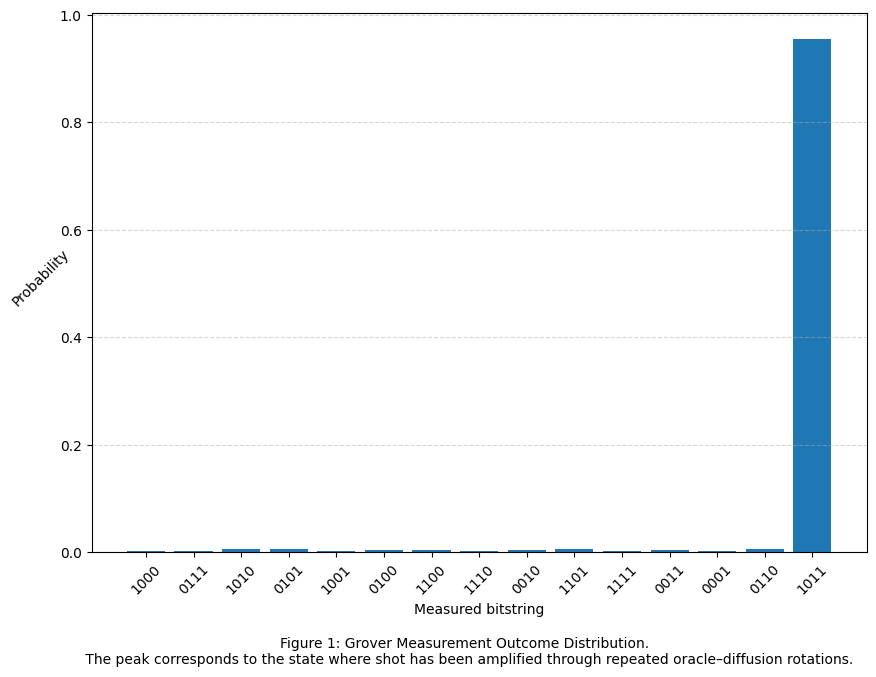

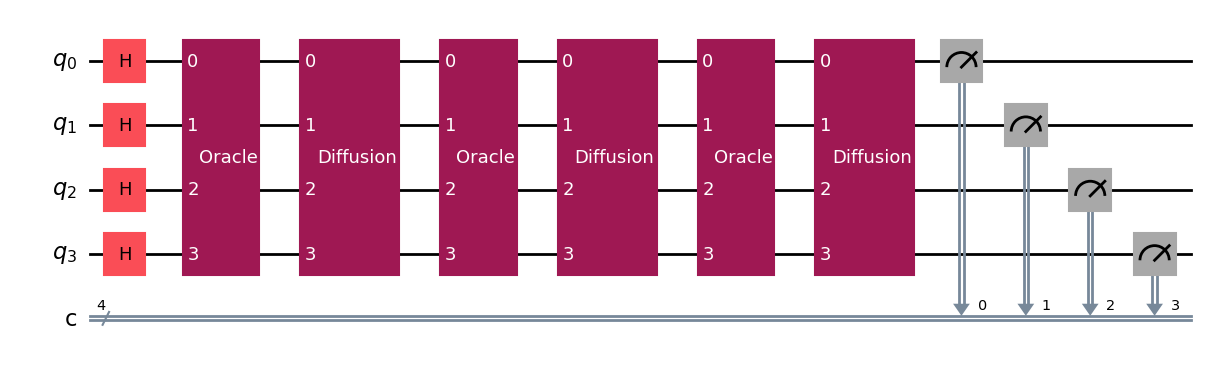

In [7]:
bitstrings = list(counts.keys())
probs = [counts[b] / shots for b in bitstrings]

plt.figure(figsize=(10,7))
plt.bar(bitstrings, probs)
plt.xlabel("Measured bitstring")
plt.ylabel("Probability", rotation=45, labelpad=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.figtext(0.5, -0.05,
    "Figure 1: Grover Measurement Outcome Distribution. \n The peak corresponds to the state where shot has been amplified through repeated oracle–diffusion rotations.",
    ha="center", fontsize=10)
plt.show()
qc.draw('mpl')


**Figure 2a:** *Grover circuit for a 4-qubit search.*  
Each iteration consists of an **Oracle** (marking the target state) followed by **Diffusion**.  
The sequence of H gates opens the superposition and the final measurement extracts the amplitudes.  

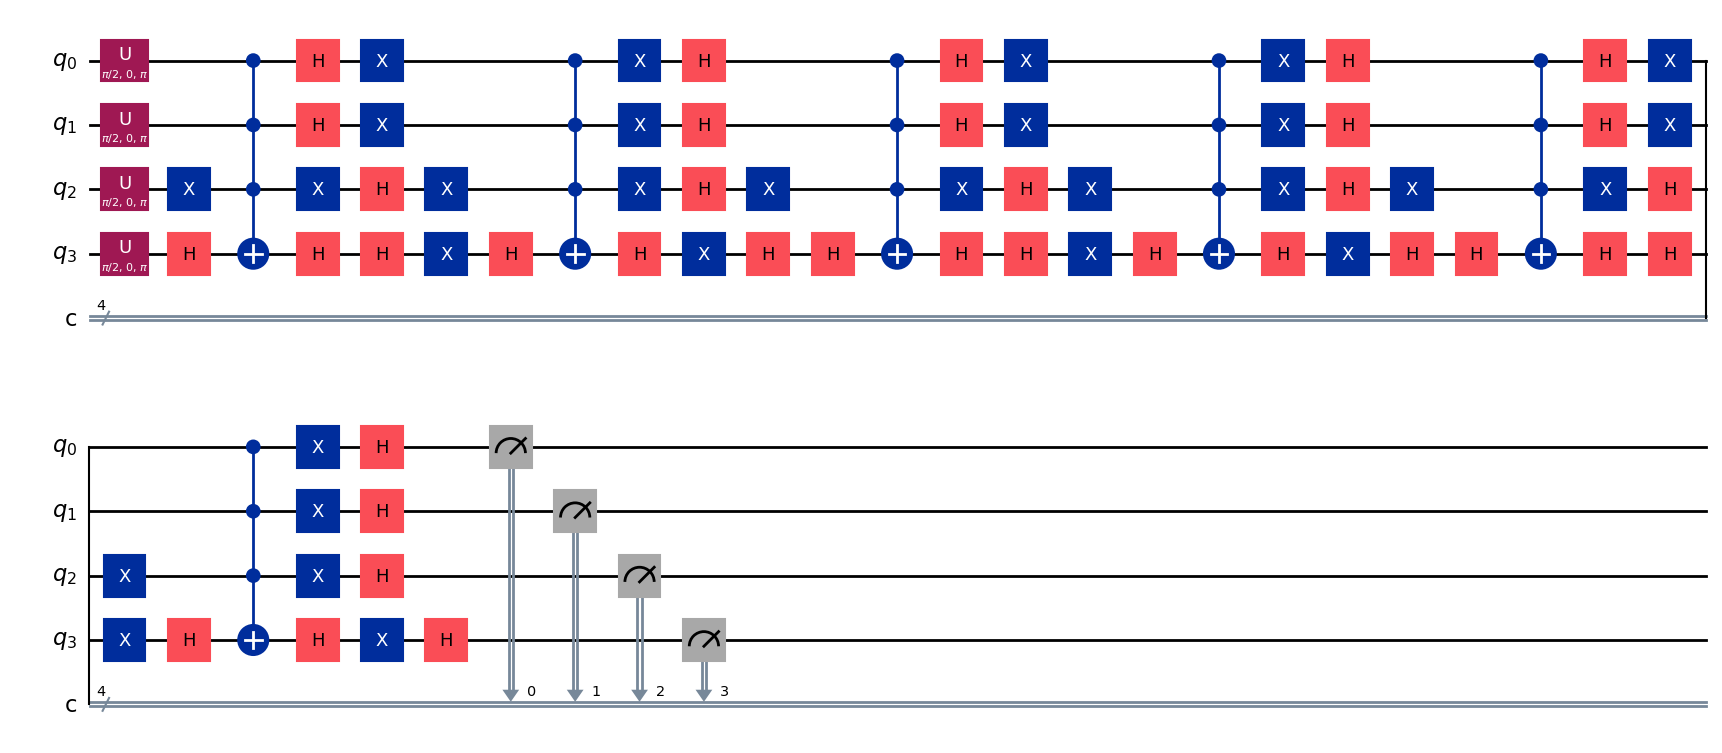

In [8]:
qc.decompose().draw('mpl')

**Figure 2b:** Decomopsed Grover circuit for a 4-qubit search

The diagram above shows the decomposed version of your Grover circuit. Instead of displaying high-level blocks (“Oracle”, “Diffusion”), Qiskit expands everything into the elementary gates that a quantum computer would execute.

Top Panel - These repeating patters correspond to Oracle and Diffusion Operators, each sequence serves as one iteration (here T = 3 hence 3 repeats)
- This is the circuit *before measurement* we see repeated blocks:
    - H gates: These either create a superposition or undo the phase kickback
    - X gates: These flip the computational basis states
    - MCX (multi-controlled X) gates: These implement phase flips and multi-qubit logic

Bottom Panel — Measurement Stage
- After the Grover iterations finish, the circuit ends with measurements on all qubits.
- the measurement gates (grey symbols) send classical outcomes to the classical bits.

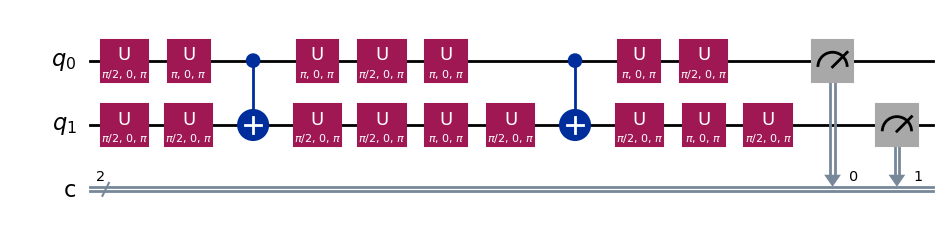

In [9]:
qc, T, n_qubits, N = grover_circuit('10')
qc.decompose(reps=10).draw('mpl')

**Figure 2C:** Further Decomopsed Grover circuit for a 2-qubit search (here I reduced the number of qubits to reduce output size)

The diagram above shows the **fully** decomposed version of your Grover circuit. `reps=10` instructed Qiskit to continue decomposing until the most basic structure
- The repeated `U(π/2, 0, π)` gates implement the Hadamard and phase-operations - in both Oracle and Diffusion
- The CX gate is the gate that flips the phase of the target state and then perform the inversion
- The measurement is then recorded - the grey meter at the end

Aside: We see different type of symbols occuring here
1. $U(\theta,\phi,\lambda)$ is for a single qubit and is unitary, it generates single qubit rotation or phase shift
2. A CX Gate is a 2 qubit controlled-NOT gate that flips the target qubit when the control qubit is in state $|1\rangle$

---


**Section 1. Part 4 – Scaling Analysis**

- We have now validated that both `classical_hack` and `grover_circuit` correctly locate a given `secret_bitstring`.
- The next step is to understand how the required number of *operations* scales as the size of the search space increases.

We consider *Number of Operations* rather than *time* because it is not hardware dependent.

- **Classical:** the number of guesses (lock queries) made before the secret is found  
- **Quantum:** the number of oracle calls used by Grover’s algorithm (i.e., the number of Grover iterations)



**Here we make 2 changes to the test:**
1. For each bit value of k (where k is the bitstring length), we generate a new secret_bitstring, and repeat the test.

2. This process is repeated 1024 times so we can calculate average number of queries required, and compare to the expected number required.
    - For classical we expect to see $O(N)$, i.e. *Number of Opertations* scales lineaerly with N possible states
    - For quantum we expect to see that  $O(\sqrt N)$ i.e. *Number of Opertations* scales *proportionally* to $\sqrt N$


### 

**Note:** We begin scaling analysis at **n = 2**, because Grover’s algorithm is not meaningful for $n \in [0,1]$ where the search space is too small for amplitude amplification to behave as expected.



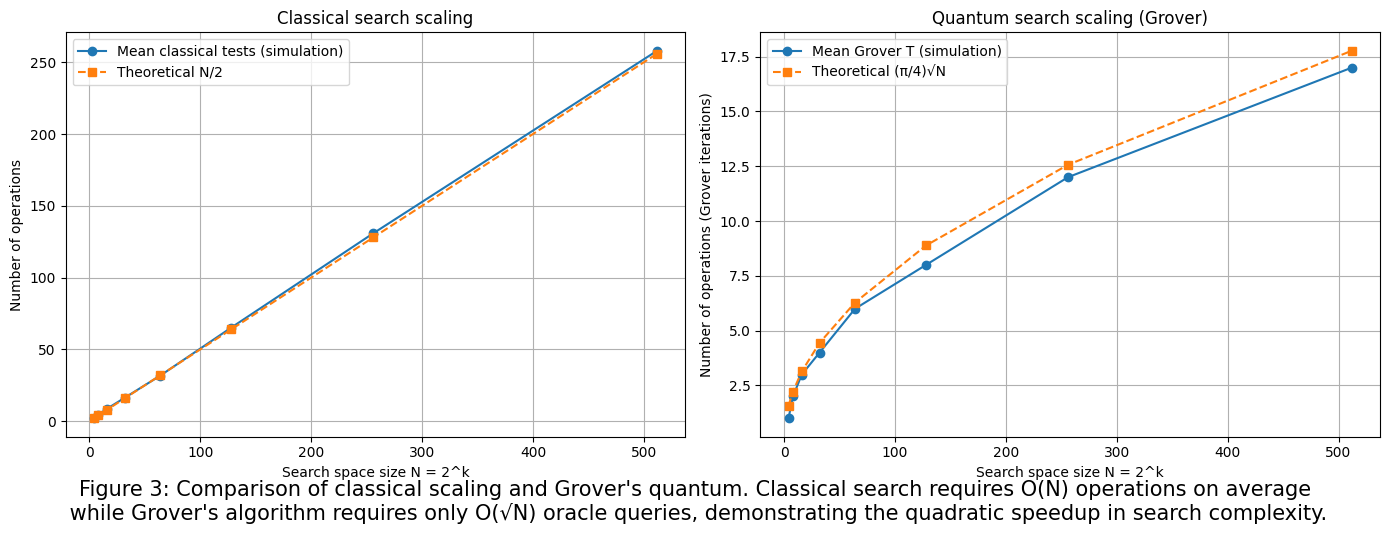

In [10]:
n_repeats = 1024
ks = range(2, 10)
results_tests = {k: [] for k in ks}

for _ in range(n_repeats):
    df_bitstrings = generate_random_bitstrings()
    for k in ks:
        result = test_classical(df_bitstrings, k)
        n_tests = result["queries"]
        results_tests[k].append(n_tests)
summary = []
for k in ks:
    n_tests_list = [x for x in results_tests[k] if x is not None]
    mean_n_tests = np.mean(n_tests_list)
    N = 2**k
    summary.append([k, N, mean_n_tests, N/2])
df_summary = pd.DataFrame(summary,columns=["k", "N = 2^k", "Mean n tests required", "Theoretical n tests required"])

quantum_Ts = []
sim = AerSimulator() #Use of Qiskit.Aer as outlined in the intro
for k in ks:
    N = 2**k
    secret_bitstring = format(np.random.randint(0, N), f"0{k}b")
    qc, T, n_qubits, N_grover = grover_circuit(secret_bitstring)
    quantum_Ts.append(T)
df_summary["Mean Grover T (quantum operations)"] = quantum_Ts
df_summary["Theoretical Grover T = (π/4)√N"] = (np.pi/4) * np.sqrt(df_summary["N = 2^k"])

N_vals = df_summary["N = 2^k"]
y_classical_mean = df_summary["Mean n tests required"] # Classical
y_classical_theory = df_summary["Theoretical n tests required"]
y_grover_mean = df_summary["Mean Grover T (quantum operations)"] # Quantum
y_grover_theory = df_summary["Theoretical Grover T = (π/4)√N"]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].plot(N_vals, y_classical_mean, marker="o", label="Mean classical tests (simulation)")
axs[0].plot(N_vals, y_classical_theory, marker="s", linestyle="--", label="Theoretical N/2")
axs[0].set_xlabel("Search space size N = 2^k")
axs[0].set_ylabel("Number of operations")
axs[0].set_title("Classical search scaling")
axs[0].grid(True)
axs[0].legend()
axs[1].plot(N_vals, y_grover_mean, marker="o", label="Mean Grover T (simulation)")
axs[1].plot(N_vals, y_grover_theory, marker="s", linestyle="--", label="Theoretical (π/4)√N")
axs[1].set_xlabel("Search space size N = 2^k")
axs[1].set_ylabel("Number of operations (Grover iterations)")
axs[1].set_title("Quantum search scaling (Grover)")
axs[1].grid(True)
axs[1].legend()
plt.tight_layout()
plt.figtext(0.5, -0.05,
    "Figure 3: Comparison of classical scaling and Grover's quantum. Classical search requires O(N) operations on average\n while Grover's algorithm requires only O(√N) oracle queries, demonstrating the quadratic speedup in search complexity.",
    ha="center", fontsize=15)
plt.show()

### Section 2
**Intro:** Figure 3 indeed showcases that T scales with $\sqrt N$, however *this was coded in when we set* `T = int(np.floor((np.pi / 4) * np.sqrt(N)))`. Now our goal is to understand why this expression arises.

---

### **Objectives**

Investigate why Grover's algorithm scales with $\sqrt N$, specifically why optimal `T = int(np.floor((np.pi / 4) * np.sqrt(N)))`

Prove that T is a repeating function and explain how to calculate it for different N

---

### **Method**

1. **Investigate how varying T value affect the success rate of Grover's Algorithm for a bitstring of length 3**

2. **Notice a pattern for the optimal T value, show and explain why it is periodic**

3. **Fit the periodic pattern to a sinusoidal function**

4. **Scale the analysis to investigate how the optimal value of T changes with a different number of qubits**

5. **Plot optimal T value as a function on n qubits and N = 2^n sample size**

In [11]:
#Oracle and Diffusion operators are identical for this section, however investigating the behaviour of the circuit for different T values means T is *free parameter*

def grover_circuit(secret_bitstring, T):
    n_qubits = len(secret_bitstring)
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    O = oracle(secret_bitstring).to_gate()
    D = diffusion(n_qubits).to_gate()
    for _ in range(T):
        qc.append(O, range(n_qubits))
        qc.append(D, range(n_qubits))
    qc.measure(range(n_qubits), range(n_qubits))
    return qc # Here we don't need to return T, n_qubits or N, we will define them within analysis for more control

#Also defined is run_grover_experiment function, for each value of T this builds and simulates grover_circuit
def run_grover_experiment(secret_bitstring, T_values, sim, shots):
    results = []
    for T in T_values:
        qc = grover_circuit(secret_bitstring, T)
        qc_t = transpile(qc, sim)
        result = sim.run(qc_t, shots=shots).result()
        counts = result.get_counts()
        success_prob = counts.get(secret_bitstring, 0) / shots
        results.append(success_prob)
    return np.array(results)

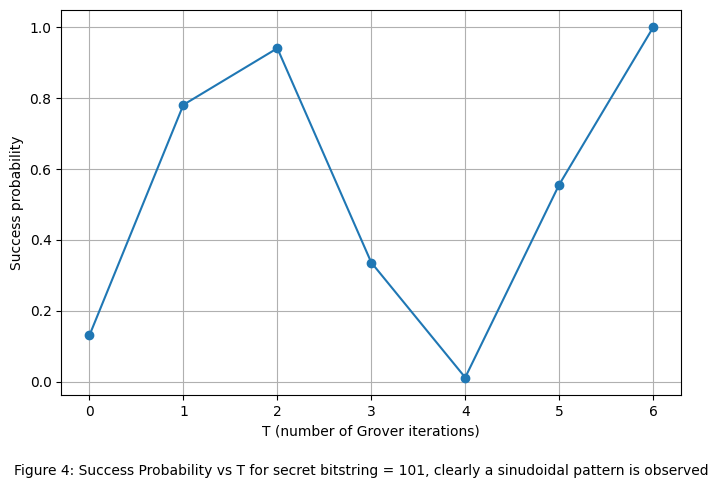

In [12]:
#1 Investigate how varying T value affect the success rate of Grover's Algorith for a bitstring of length 3
# We define secret_bitstring = "101", with n = 3 for quick runtime
#T_max = ⌈2√N⌉ was chosen so the whole peak was covered and some over-rotation could also be seen 
secret_bitstring = "101"
n_qubits = len(secret_bitstring)
N = 2**n_qubits
T_max = int(np.ceil(2 * np.sqrt(N)))
T_values = list(range(0, T_max + 1))
sim = AerSimulator()
shots = 2048
success_probs = run_grover_experiment(secret_bitstring, T_values, sim, shots)
plt.figure(figsize=(8, 5))
plt.plot(T_values, success_probs, marker="o")
plt.xlabel("T (number of Grover iterations)")
plt.ylabel("Success probability")
plt.grid(True)
plt.figtext(0.5, -0.05,
    f"Figure 4: Success Probability vs T for secret bitstring = {secret_bitstring}, clearly a sinudoidal pattern is observed",
    ha="center", fontsize=10)
plt.show()

In [13]:
#We rebuild the experiment run function so that all possible bitstrings for a given n are tested, the success probabilities are then averages for all T values across all possible states

T_FACTOR = 10 #Controlling how mant T values we generate, before we used 2*√N to see the whole peak, this this we make it larger so we can see many peaks and more accurately fit
SHOTS = 2048
SIM = AerSimulator()
n_qubits = 3

def run_grover_for_all_marked_states(n_qubits): #Helper function to run Grover Experiment for all possible states of size n_qubits
    N = 2**n_qubits
    T_max = int(np.ceil(T_FACTOR * np.sqrt(N)))
    T_values = list(range(0, T_max + 1))
    bitstrings = [format(i, f"0{n_qubits}b") for i in range(N)]
    all_probs = []
    for s in bitstrings:
        probs_s = []
        for T in T_values:
            qc = grover_circuit(s, T)
            qc_t = transpile(qc, SIM)
            result = SIM.run(qc_t, shots=SHOTS).result()
            counts = result.get_counts()
            success_prob = counts.get(s, 0) / SHOTS
            probs_s.append(success_prob)
        all_probs.append(probs_s)
    all_probs = np.array(all_probs)
    mean_probs = all_probs.mean(axis=0)
    return T_values, mean_probs, all_probs, bitstrings

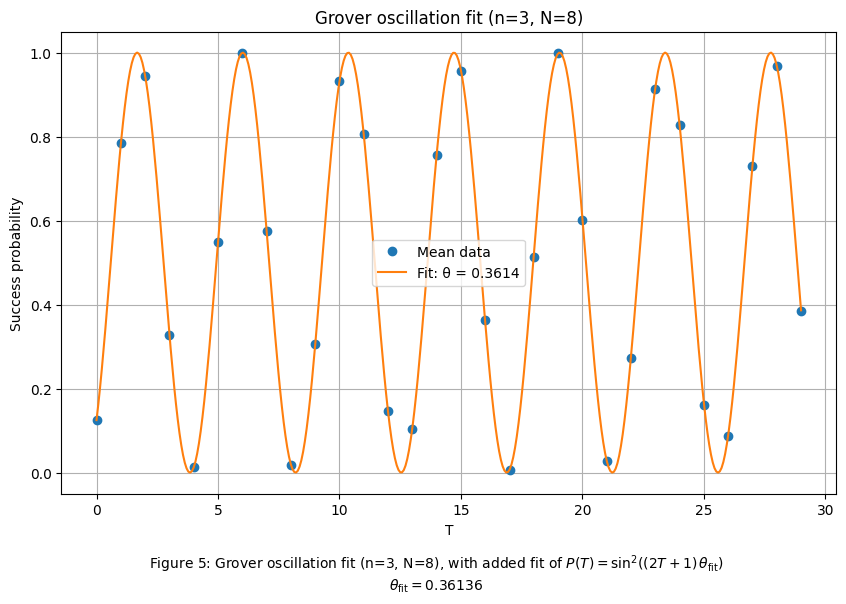

In [ ]:
#3. Fit the periodic pattern to a sinusoidal function
#Running the function, depending on how large n_qubits is this can take some time, n_qubits = 3 was chosen to reduce runtime
T_values, mean_probs, all_probs, bitstrings = run_grover_for_all_marked_states(n_qubits)
n_qubits_fit = len(bitstrings[0])      
N_fit = len(bitstrings)  
df_prob = []

for i, s in enumerate(bitstrings):
    for j, T in enumerate(T_values):
        df_prob.append({
            "bitstring": s,
            "T": T,
            "success_prob": all_probs[i][j]
        })
df_prob = pd.DataFrame(df_prob)

def grover_model(T, theta): #This it the theoretical function and is defined below, the next code block fits it to the observed data
    return np.sin((2*T + 1) * theta)**2

T_arr = np.array(T_values, dtype=float)
P_arr = np.array(mean_probs, dtype=float)
theta0 = 1/np.sqrt(N_fit)
popt, pcov = curve_fit(grover_model, T_arr, P_arr, p0=[theta0])
theta_fit = popt[0]
theta_err = np.sqrt(np.diag(pcov))[0]
T_dense = np.linspace(min(T_arr), max(T_arr), 400)
P_fit = grover_model(T_dense, theta_fit)
plt.figure(figsize=(10, 6))
plt.plot(T_arr, P_arr, "o", label="Mean data")
plt.plot(T_dense, P_fit, "-", label=f"Fit: θ = {theta_fit:.4f}")
plt.xlabel("T")
plt.ylabel("Success probability")
plt.grid(True)
plt.legend()
plt.figtext(0.5, -0.05,fr"Figure 5: Grover oscillation fit (n={n_qubits}, N={N}), with added fit of "
    r"$P(T) = \sin^2\!\left((2T + 1)\,\theta_{\mathrm{fit}}\right)$""\n" fr"$\theta_{{\mathrm{{fit}}}} = {theta_fit:.5f}$",ha="center",fontsize=10)
plt.show()

**Why do we see oscillations?**  

The plot shows that the success probability of **T** evolves when we repeatedly sample Grover's Algorithm for different **T** values.  
Rather than increasing linearly, or behaving like a Gaussian, the probability **oscillates**,  
peaking at specific values such that we can model it using `grover_model`.

## Theoretical Foundation:

To conceptualise we consider the initial part of Grover's Algorithm - the uniform superposition state $|u\rangle = H^{\otimes n} |0^n\rangle$, which is within the subspace spanned by $|A_0\rangle$ and $A_1\rangle$

**$A_0$ is the set of all non-solutions and $A_1$ is the set of all solutions**
- We can consider $|z\rangle$ = $|\text{secret\_bitstring}\rangle$ defined in `Part 1` to be an element within $|A_1\rangle$.

We define it as: $|u\rangle = \sqrt{\frac{|A_0|}{N}}\,|A_0\rangle + \sqrt{\frac{|A_1|}{N}}\,|A_1\rangle$. 

When we apply Grover's algorithm, the goal is to maximise the coefficient of $A_1\rangle$ by applying t iterations of the *Grover Operator* to $|u\rangle$

$G = (2|u\rangle\langle u| - I)\,(I - 2|A_1\rangle\langle A_1|)$.

When G is applied to the basis states $|A_0\rangle$ and $A_1\rangle$ we construct a unitary matrix M which describes as a rotation:


$M =
\begin{pmatrix}
\sqrt{\frac{|A_0|}{N}} & -\sqrt{\frac{|A_1|}{N}} \\
\sqrt{\frac{|A_1|}{N}} & \sqrt{\frac{|A_0|}{N}}
\end{pmatrix}^{2}$ = $\begin{pmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{pmatrix}^{2}$. Where $\theta = \sin^{-1}\!\left( \sqrt{\frac{|A_1|}{N}} \right).$ 

**Note**: The second matrix is called a *Givens' Rotation Matrix*. The act of squaring this is the same as applying it twice hence rewrite as:

$M =
\begin{pmatrix}
\cos(2\theta) & -\sin(2\theta) \\
\sin(2\theta) & \cos(2\theta)
\end{pmatrix}.$ So each iteration of G to $|u\rangle$, will rotate it's coefficients by $2\theta$

Additionally, the definition of $\theta$ means $|u\rangle$ can be rewritten as $|u\rangle = \cos(\theta)\,|A_0\rangle + \sin(\theta)\,|A_1\rangle$. This allows us to mathematically observe the active of applying G t times:

$G^{t} |u\rangle= \cos\!\big((2t+1)\theta\big)\,|A_0\rangle + \sin\!\big((2t+1)\theta\big)\,|A_1\rangle$. 

As stated we want to maximise $\sin\!\big((2t+1)\theta\big)$, so we set $|A_0\rangle = 0$ and normalise.



**Why did we fit?**

This act of squaring, results in the fitting function shown above: $P(T_{\text{optimal}}) = \sin^{2}\!\big((2t + T)\theta\big)$, to verify the experinment matches the theory, I fitted the data using SciPy to extract $\theta_{\text{fit}} \approx 0.3614$.

The theoretical value is $\theta_{\text{theory}} = \arcsin\left(\frac{1}{\sqrt{8}}\right) \approx 0.3614$, showcasing and identical result to any meaningful error.

**What do we interpret?**

The peaks arise from the structure of Grover's Algorithm, where each iteration rotates by $2\theta$ in a 2D subspace, the amplitude of secret_bitstring is increased up to $T_{Optimal}$

To this can be visualised as rotation around a circle - as seen below

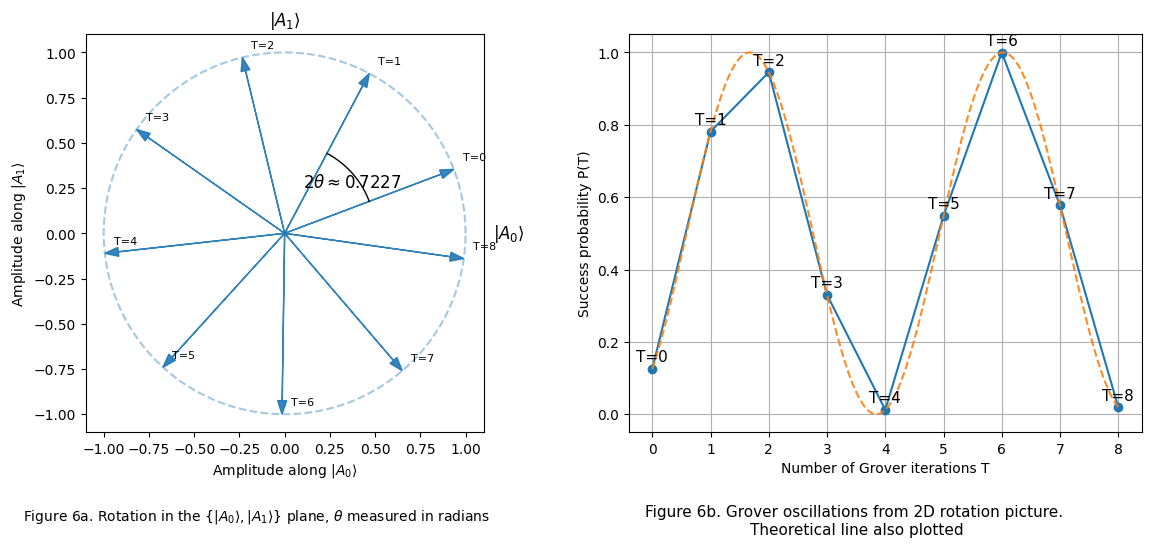

In [15]:
N = 8
theta = np.arcsin(1/np.sqrt(N))
T_max = 8
Ts = np.arange(0, T_max + 1)
x = np.cos((2*Ts + 1) * theta)
y = np.sin((2*Ts + 1) * theta)
P_success = np.sin((2*Ts + 1) * theta)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
phi = np.linspace(0, 2*np.pi, 400)
ax.plot(np.cos(phi), np.sin(phi), linestyle="--", alpha=0.4)
for T, xT, yT in zip(Ts, x, y):
    ax.arrow(0,0,xT,yT,head_width=0.05,length_includes_head=True,color="C0",alpha=0.9); ax.text(xT+0.05,yT+0.05,f"T={T}",fontsize=8)


T_theory = np.linspace(min(Ts), max(Ts), 400)  # smooth curve
P_theory = np.sin((2 * T_theory + 1) * theta)**2

ax.text(1.15, 0.0, r"$|A_0\rangle$", fontsize=12, va="center")
ax.text(0.0, 1.15, r"$|A_1\rangle$", fontsize=12, ha="center")

ax.set_xlabel(r"Amplitude along $|A_0\rangle$")
ax.set_ylabel(r"Amplitude along $|A_1\rangle$")
ax.set_aspect("equal", "box")
T0, T1 = 0, 1
angle0 = (2*T0 + 1) * theta
angle1 = (2*T1 + 1) * theta

arc_angles = np.linspace(angle0, angle1, 100)
arc_r = 0.5
arc_x = arc_r * np.cos(arc_angles)
arc_y = arc_r * np.sin(arc_angles)
theta_str = f"{2*theta:.4f}"
ax.plot(arc_x, arc_y, color="black", linewidth=1)
ax.text(
    arc_r * np.cos((angle0+angle1)/2),
    arc_r * np.sin((angle0+angle1)/2),rf"$2\theta \approx {theta_str}$",fontsize=12,ha="center",va="top")
ax.grid(False)


ax = axes[1]
ax.plot(Ts, P_success, marker="o")
for T, p in zip(Ts, P_success):
    ax.text(T, p + 0.02, f"T={T}", ha="center", fontsize=11)
ax.plot(T_theory, P_theory, linestyle="--", label="Theoretical", alpha=0.9)
ax.set_xlabel("Number of Grover iterations T")
ax.set_ylabel("Success probability P(T)")
ax.grid(True)
fig.text(0.25, -0.05,r"Figure 6a. Rotation in the $\{|A_0\rangle, |A_1\rangle\}$ plane, $\theta$ measured in radians",ha="center", fontsize=10)
fig.text(0.75, -0.02,f"Figure 6b. Grover oscillations from 2D rotation picture. \nTheoretical line also plotted",ha="center",va="top",fontsize=11)
plt.tight_layout()
plt.show()

**Why We Use np.floor - i.e. round down**

As demonstrated, the ideal value for T is therefore $T_{\text{ideal}} = \frac{\pi}{4\theta} - \frac{1}{2}$

However, \(T\) must be an *integer* because it is the number of times we apply \(G\). 

**We round down for 2 reasons:**

1. Rounding down means the algorithm stops before the peak, hence reducing the likelihood of over-rotation

2. Rounding down reduces iteration count, hence saving computational time

---

**4.  Scale the analysis to investigate how the optimal value of T changes with a different number of qubits**

At this point we don't need to observe repeating functions, so T_FACTOR is reduced, this also improves runtime

The function analyse_peaks_for_n is written to serve the following purposes:

1. Run Grover’s algorithm for all states of size n_qubits
2. Average the success probability across all possible states
3. Fit the curve as above
4. Extracts the theoretical peak locations (where success probability hits 1)
5. Returns a DataFrame of peak numbers vs fitted T values, plus the fitted θ parameter

Step 4 and 5 are the key parts because they will allow us to model how the optimal T value changes with n qubits, from this we should experimentally show that Grover's algorithm scales with $\sqrt N$

**Aside: Here I chose to fit actual peak T value, note that in reality this is impossible as $T \in \mathbb{Z}$, i.e. it is impossible to have afractional number of iterations.

In [16]:
T_FACTOR = 2
def analyse_peaks_for_n(n_qubits):
    T_values, mean_probs, all_probs, bitstrings = run_grover_for_all_marked_states(n_qubits=n_qubits)
    N_fit = len(bitstrings)
    T_arr = np.array(T_values, dtype=float)
    P_arr = np.array(mean_probs, dtype=float)
    theta0 = 1 / np.sqrt(N_fit)
    popt, pcov = curve_fit(grover_model, T_arr, P_arr, p0=[theta0])
    theta_fit = popt[0]
    theta_err = np.sqrt(np.diag(pcov))[0]
    T_max = T_arr.max()
    peak_numbers = []
    T_peaks = []
    k = 0
    while True:
        T_k = ((2 * k + 1) * np.pi / (2 * theta_fit) - 1) / 2
        if T_k < 0:
            k += 1
            continue
        if T_k > T_max:
            break
        peak_numbers.append(k + 1)
        T_peaks.append(T_k)
        k += 1
    df_peaks = pd.DataFrame({"Peak No.": peak_numbers,f"Fitted T value for {n_qubits} qubits": T_peaks})
    return df_peaks, theta_fit

In [17]:
#Increasing n beyond 6 increases the runtime too much
dfs = {}
for n in [2, 3, 4, 5, 6]:
    df_n, _ = analyse_peaks_for_n(n_qubits=n)
    dfs[n] = df_n.set_index("Peak No.")
for n, df in dfs.items():
    df.columns = [f"Fitted T value for {n} qubits"]
df_summary = None
for df in dfs.values():
    if df_summary is None:
        df_summary = df.copy()   # initialise
    else:
        df_summary = df_summary.merge(df, left_index=True, right_index=True)
df_summary = df_summary.reset_index()

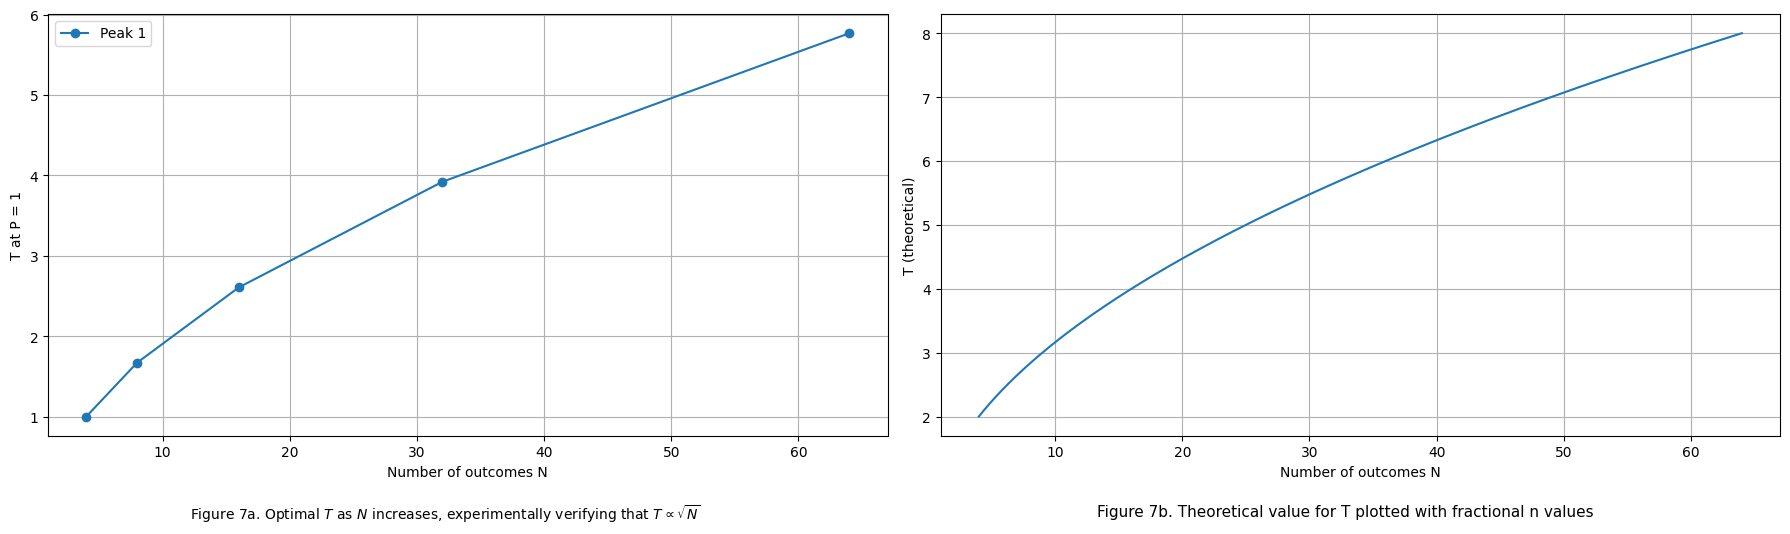

In [18]:
qubit_cols = [col for col in df_summary.columns if "Fitted T value for" in col]
qubit_numbers = [int(col.split("for")[1].strip().split()[0])  for col in qubit_cols]
N_values = [2**n for n in qubit_numbers]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
ax = axes[0]
for idx, row in df_summary.iterrows():
    peak_no = int(row["Peak No."])
    T_values = row[qubit_cols].values
    ax.plot(N_values, T_values, marker="o", label=f"Peak {peak_no}")

ax.set_xlabel("Number of outcomes N")
ax.set_ylabel("T at P = 1")
ax.grid(True)
ax.legend()

ax = axes[1]
N_smooth = np.linspace(min(N_values), max(N_values), 300)
T_smooth = np.sqrt(N_smooth)
ax.plot(N_smooth, T_smooth)
ax.set_xlabel("Number of outcomes N")
ax.set_ylabel("T (theoretical)")
ax.grid(True)
fig.text(0.25, -0.05,r"Figure 7a. Optimal $T$ as $N$ increases, experimentally verifying that $T \propto \sqrt{N}$ ",ha="center", fontsize=10)
fig.text(0.75, -0.02,f"Figure 7b. Theoretical value for T plotted with fractional n values",ha="center",va="top",fontsize=11)
plt.tight_layout()
plt.show()

This concludes section 2

I have explained and shown why Grover's Algorithm scales with $\sqrt N$

To do this I have modelled Grover's Algorithm for different values of T (repetitions) locating the optimal value of T for 2 - 6 qubits and linked this to theory as well as plotting the observed vs theoretical value for T as a function of N

---

## Section 3. Using Grover's Algorithm With a Treasure Map (mini example)
***Objectives***

- In the standard Grover setup, the oracle marks a **single state** by equality (i.e., “this exact bitstring is the solution”).  
- In the treasure-map version, the oracle instead marks **all states satisfying a property** (e.g., “even”, “greater than X”, “multiple of 3”), turning the search into a constraint-satisfaction problem.  
---

### Updating the Oracle to “Greater  Than”

Previously, the oracle **marked a single basis state** `|z⟩` by checking *equality* with a bitstring. Now we change so that the oracle marks **all states greater than a chosen threshold**


The key changes:
- We interpret the threshold bitstring as an integer `threshold_int` and use an `IntegerComparator` (see below).
  
- The circuit now acts on the full register $|z\rangle$ plus ancillas, with the **last qubit used as a flag** that records if the inequality is satisfied.

Conceptually, this moves to **search by inequality**, so the marked set can contain **multiple** solutions instead of just one

**New concept: Ancillas**

*IBM Documentation*: An extra qubit that is used to help implement operations on other qubits, but whose final state is not important for the program.(IBM)

In essence it is an extra qubit that is added to allow us to do certain operations. It can be used to improve a quantum search algorithm by controlling transformations (Tulsi)

They are used in *classical computing* as a way to 'allow extra working space during computation' (Nielsel)

**New concept: IntegerComparator**

*IBM Documentation* : Operator compares basis states $|i\rangle_n$ against a classically given integer  $L$ of fixed value, and flips a target qubit if  
$i \geq L$ (or $i < L$), depending on the parameter `geq`. Setting `geq = True` gives greater than, `geq = False` gives less than. (IBM)

This is a quantum subcircuit that we can use to test whether an integer satisfied a greater than or less than value: $z \ge (\text{threshold\_int} + 1) \;\;\Longleftrightarrow\;\; z > \text{threshold\_int}.$

**Definition: Data Qubits**
- Another name for the qubits considered above. The data qubit here represents every possible candidate that could be the secret value i.e. the search register

**Definition: Flag Qubits**
- A qubit that the oracle flips when it has found the correct solution i.e. a target/output qubit

In [19]:
def oracle_greater_than(threshold_bitstring):
    # Generalised oracle: mark *all* states with z > threshold, using IntegerComparator
    n = len(threshold_bitstring)
    threshold_int = int(threshold_bitstring, 2)

    # Use Qiskit's IntegerComparator to encode the inequality z ≥ (threshold + 1) ⇔ z > threshold
    comp = IntegerComparator(num_state_qubits=n,value=threshold_int + 1,geq=True)
    # Extract full qubit layout from the comparator: [data | flag | ancillas]
    num_state = comp.num_state_qubits       # qubits storing z
    num_anc   = comp.num_ancillas           # work qubits used internally
    num_total = comp.num_qubits             # data + flag + ancillas

    qc = QuantumCircuit(num_total)
    data_qubits    = list(range(num_state))
    flag_qubit     = num_state              # comparator flag qubit (z ≥ threshold+1 ?)
    ancilla_qubits = list(range(num_state + 1, num_total))

    # Turn the comparator into a gate so we can compute / uncompute it cleanly
    comp_gate = comp.to_gate(label="cmp>=x+1")
    comp_dg   = comp_gate.inverse()
    all_qubits = list(range(num_total))

    # 1) Compute the comparison and write the result into the flag qubit
    qc.append(comp_gate, all_qubits)

    # 2) Apply a Z phase flip controlled by the comparator outcome
    qc.z(flag_qubit)

    # 3) Uncompute the comparator to reset flag + ancillas back to |0⟩
    qc.append(comp_dg, all_qubits)

    return qc

In [20]:
def grover_circuit_greater_than(threshold_bitstring):    # Generalised Grover: mark ALL states with z > threshold using the comparator oracle
    n_qubits = len(threshold_bitstring)
    N = 2 ** n_qubits
    threshold_int = int(threshold_bitstring, 2)

    
    M = N - (threshold_int + 1) # Number of marked states M = |{ z : z > threshold }| = N - (threshold+1)

    
    if M <= 0: # Checks that the problem will work
        raise ValueError(f"No marked states for threshold {threshold_int} in domain [0,{N-1}]. ""Choose a smaller threshold.")
    T = int(np.floor((np.pi / 4) * np.sqrt(N / M))) # Grover iteration count now depends on *how many* states satisfy z > threshold
    if T == 0:
        raise ValueError(f"Grover iteration count T=0 for threshold {threshold_int} "f"(N={N}, M={M}). Too many marked states for amplification.")

    comp = IntegerComparator(num_state_qubits=n_qubits,value=threshold_int + 1,geq=True) # Use comparator only to determine total qubits needed: data + flag + ancillas
    num_total = comp.num_qubits

    data_qubits    = list(range(n_qubits))     # Data qubits still represent the binary string z
    ancilla_qubits = list(range(n_qubits, num_total))  # extra qubits used by the comparator

    qc = QuantumCircuit(num_total, n_qubits)
    qc.h(data_qubits) # Prepare uniform superposition on the *data* qubits; ancillas remain |0⟩

    O = oracle_greater_than(threshold_bitstring).to_gate(label="Oracle: > x") # Oracle now uses IntegerComparator internally, marking ALL z > threshold

    D = diffusion(n_qubits).to_gate(label="Diffusion") # Diffusion unchanged — still acts only on the n data qubits
    
    for _ in range(T): # Grover loop: oracle acts on all qubits, diffusion only on the data
        qc.append(O, range(num_total))   # uses data + flag + ancillas
        qc.append(D, data_qubits)
    qc.measure(data_qubits, range(n_qubits))

    return qc, T, n_qubits, N

**Test: Identify all states encoding integers strictly less than 15 within a 5-qubit computational domain (size 32)**
- Classically we'd be required to check each of the 32 values
- With Grover we can use the above function and obtain with N/M tests
- `IntegerComparator` means we are free to move between decimals and bitstrings without the need for a helper function

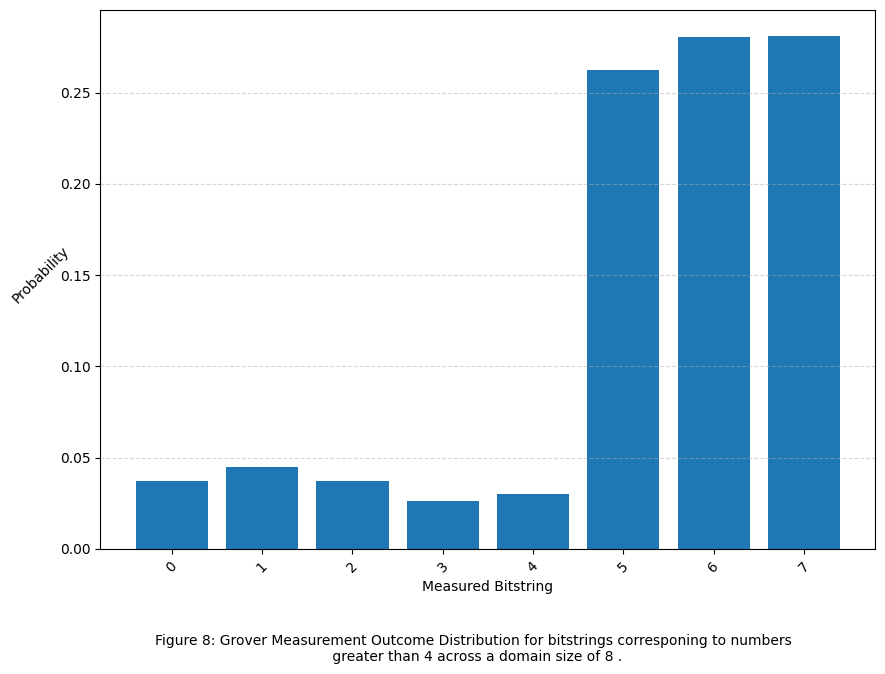

T = 1
counts = {'101': 269, '000': 38, '010': 38, '100': 31, '110': 287, '001': 46, '011': 27, '111': 288}
prob(111) = 0.28125


In [ ]:
secret_bitstring = '100'

qc, T, n_qubits, N = grover_circuit_greater_than(secret_bitstring)
sim = AerSimulator()
shots = 1024
qc_t = transpile(qc, sim)
result = sim.run(qc_t, shots=shots).result()
counts = result.get_counts()

measured_string = max(counts, key=counts.get)
prob_measured = counts[measured_string] / shots
grover_success = lock(measured_string)

bitstrings = list(counts.keys())
int_labels = [int(b, 2) for b in bitstrings]
probs = [counts[b] / shots for b in bitstrings]

plt.figure(figsize=(10,7))
plt.bar(int_labels, probs)
plt.xlabel("Measured Bitstring")
plt.ylabel("Probability", rotation=45, labelpad=10)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.figtext(0.5, -0.05,
    "Figure 8: Grover Measurement Outcome Distribution for bitstrings corresponing to numbers \n greater than 4 across a domain size of 8.",
    ha="center", fontsize=10)
plt.show()

print("T =", T)
print("counts =", counts)
print("prob(111) =", counts.get('111', 0) / shots)

**How Many Tests?**

- To perform this 'filtering', with a classical algorithm we would still need to test every state
- With the Grover-based method we built here we are able obtain the same result with $T \propto \!\left(\sqrt{\frac{N}{M}}\right)$
- Note: When M is too large the code won't run as $T = 0$
- In this case we would build the required function to measure states less than x. However we can equally build a 'bounds' version

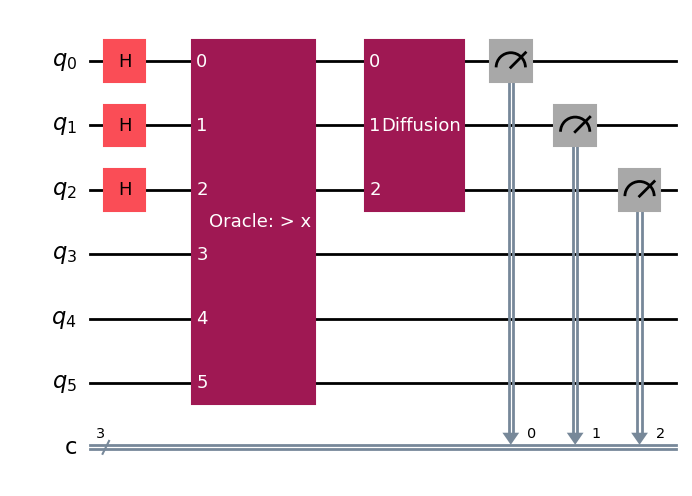

In [22]:
qc.draw('mpl')


**Figure 9:** Grover Circuit for *greater than* Oracle from above
- $q_0$ - $q_2$ represent the data qubits, hence why their superposition is opened by the H gates
- $q_3$ - $q_5$ represent the ancilla + flag qubits that the oracle use

1. H gates create a superposition with $q_0$ - $q_2$, forming the starting point for the Oracle
2. The Comparator-based Oracle marks all states that meet the condition $\boldsymbol{>} x$.
3. The Diffusion then amplifies the amplitude of marked states
4. Measurement occurs as seen before


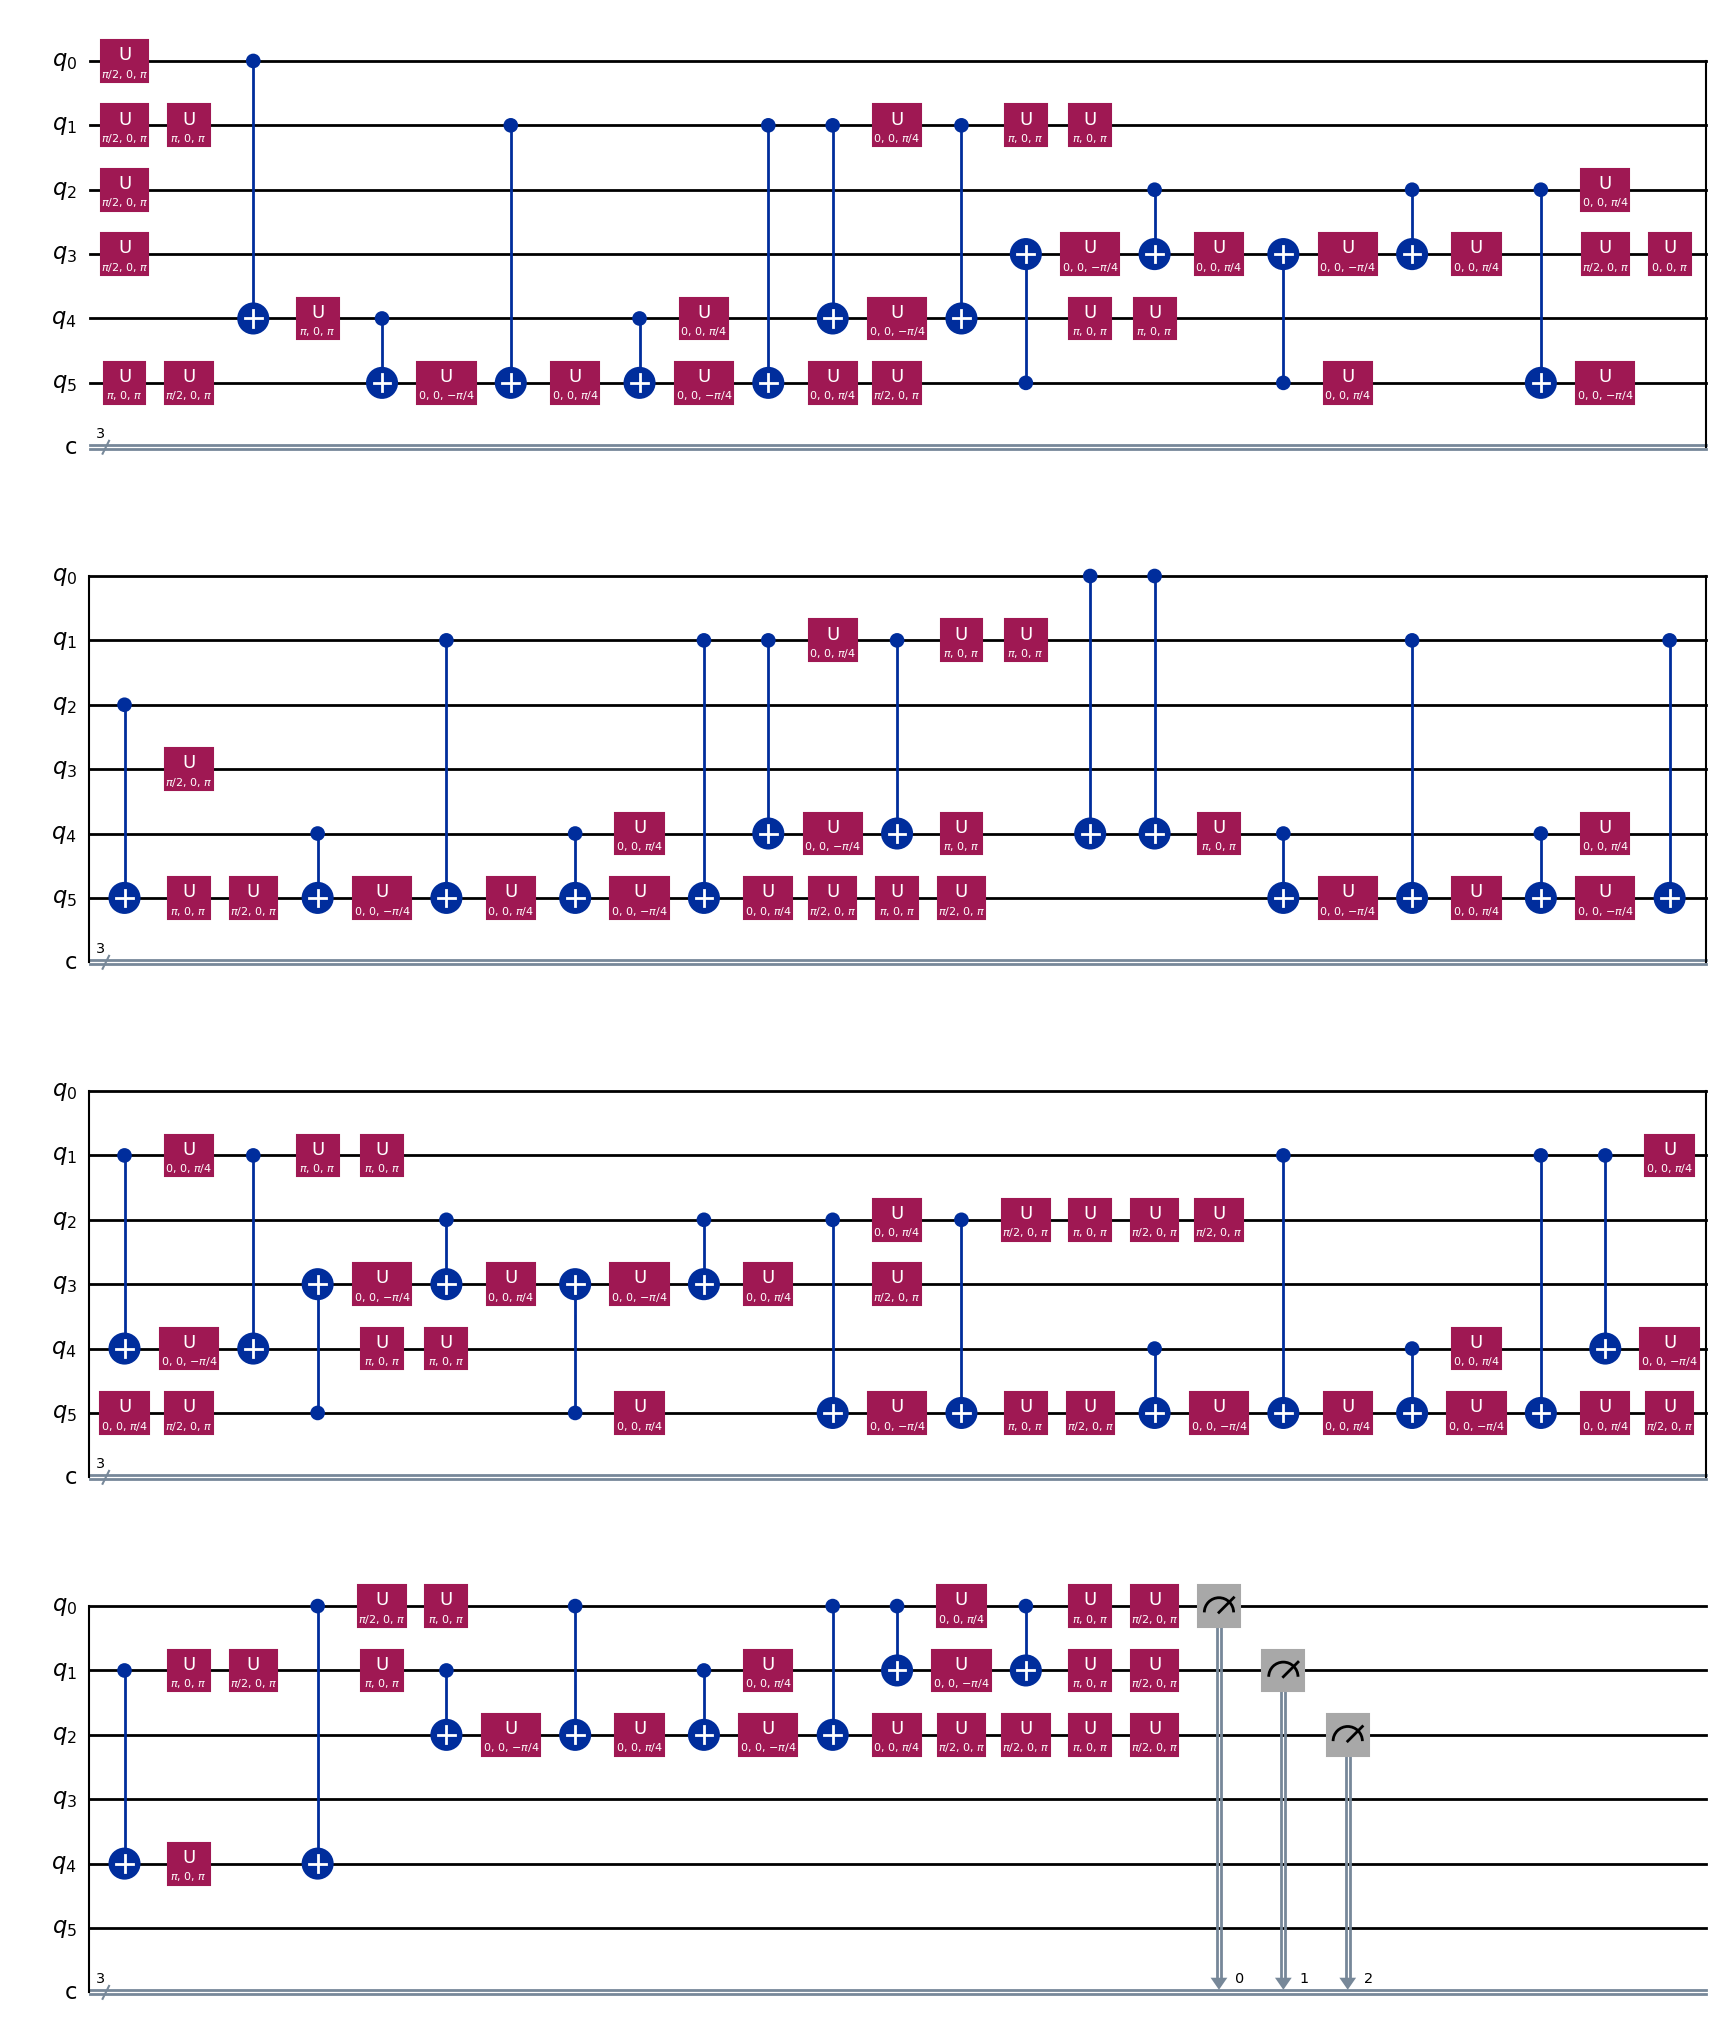

In [23]:
qc, T, n_qubits, N = grover_circuit_greater_than('100')
qc.decompose(reps=10).draw('mpl')

**Figure 9b:** Decomposed Grover Circuit for *greater than* Oracle

- The operations seen on $q_3$ to $q_5$ correspond to the comparator, which uses them to store values. They are not part of the diffusion or measurement as seen at the end of the circuit.
- Although it (looks at the start of the circuit) like they have single qubit gates applied to them, this is not the case and they exist only for the `IntegerComparator`. They start in the $|0\rangle$ state and are returned to this at the end

---


## Section 4: Grover's Algorithm For Development (Limitations)



1. On a large scale, Grover's Algorithm would still require many oracle queries, in practice this results in long circuits that are sensitive to noise. This means the error rate is too high for any meaningful conclusions to be drawn (Preskill). Current 'NISQ' (Noisy Intermediate-Scale Quantum) technology doesn't have the number of qubits required, or the error correction for large scale Grover.

2. Oracle Construction may be computationally expensive, as data would need to be 'loaded' into the Oracle. Additionally, a real oracle would have a structure. If we could understand this structure then a classical algorithm would be able to exploit it (Stoudenmire). Furthermore the benefits exist when the oracle is difficult to simultae.

3. The speedup rate of $\sqrt N$, although quicker than classical, is not at the same scale as other quantum algorithms, for example Shor's algorithm provides an expontial speedup.

4. Once a database is structured, the quantum advantage disappears. An earlier version of section 1 had a 'bitwise' feedback option for the classical search, here we would've observed how a classical algorithm could refine each bit independently - essentially honing in on the correct in potentially $O(n)$ steps, therefore reducing the quantum asymptotic advantage.

## Section 5: Acknowledgements and References

**Explicitly Referenced Information**

Lov K. Grover: A fast quantum mechanical algorithm for database search

URL: https://dl.acm.org/doi/pdf/10.1145/237814.237866

3Blue1Brown: But what is quantum computing? (Grover's Algorithm) 

URL: https://www.youtube.com/watch?v=RQWpF2Gb-gU

Nielsel - Quantum Computation and Quantum Information

URL: https://www.cambridge.org/highereducation/books/quantum-computation-and-quantum-information/01E10196D0A682A6AEFFEA52D53BE9AE#contents

Ancilla - IBM Documentation

URL: https://quantum.cloud.ibm.com/docs/en/api/qiskit/circuit  

Tulsi - General framework for quantum search algorithms

URL: https://arxiv.org/pdf/0806.1257

IntegerComparator - IBM Documentation

URL: https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.IntegerComparator

J. Preskill - Quantum Computing in the NISQ era and beyond 

URL: https://arxiv.org/abs/1801.00862

E. M. Stoudenmire and Xavier Waintal - Opening the Black Box inside Grover's Algorithm 

URL: https://journals.aps.org/prx/abstract/10.1103/PhysRevX.14.041029

A. Montanaro - Quantum algorithms: an overview

URL: https://arxiv.org/abs/1511.04206

**Acknowledgements - Used In Idea and Project Development**


Solving-TSP-Grover - https://github.com/Naphann/Solving-TSP-Grover

Building the integer comparator - https://github.com/Qiskit/qiskit/blob/main/qiskit/circuit/library/arithmetic/integer_comparator.py

Grover's Escape Room -the-quantum-grover-lab: Quantum vs Classical Search https://github.com/simransummermalik/the-quantum-grover-lab?tab=readme-ov-file

Grover's algorithm - IBM Documentation - https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers
